In [189]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import json
import os

In [190]:
raw_files = ["kariyer.jsonl", "techcareer.jsonl", "youthall.jsonl", "indeed.jsonl", "linkedin.jsonl"]
raw_data = []

for file in raw_files:
    path = f"../data/raw/{file}"
    if os.path.exists(path):
        with open(path, 'r', encoding='utf-8') as f:
            for line in f:
                if line.strip():
                    raw_data.append(json.loads(line))

df_raw = pd.DataFrame(raw_data)
print(f"Total Number of Raw Listings: {len(df_raw)}")

Total Number of Raw Listings: 3119


In [191]:
df_raw.shape

(3119, 12)

In [192]:
df_raw.head()

,Platform,Search_Keyword,Job_Title,Company,Location_Details,Job_Type,Job_Description,Job_Link,Logo_Link,Withdrawal_Date,Required_Skills,Posting_Type
0,Kariyer.net,veri bilimi,AR-GE Analitik Geliştirme Uzmanı,Vem İlaç San. ve Tic. A.Ş.,Kırklareli\nİş Yerinde,Not specified,"VEM İlaç, merkezi İstanbul’da bulunan, %100 ye...",https://www.kariyer.net/is-ilani/vem-ilac-san-...,https://img-kariyer.mncdn.com/mnresize/150/150...,2026-07-19,NaN,NaN
1,Kariyer.net,veri bilimi,Yapay Zeka (Aı) Proje Uzmanı,Arıkan Mağazacılık,İstanbul\nİş Yerinde,Not specified,Arıkan Group olarak portföyümüzde var olan her...,https://www.kariyer.net/is-ilani/arikan-magaza...,https://img-kariyer.mncdn.com/mnresize/150/150...,2026-07-19,NaN,NaN
2,Kariyer.net,veri bilimi,Veri Yönetimi ve Analitiği Koordinatörü,Lokman Hekim Sağlık Grubu,Ankara\nİş Yerinde,Not specified,Lokman Hekim Üniversitesi Araştırma Dekanlığı ...,https://www.kariyer.net/is-ilani/lokman-hekim-...,https://img-kariyer.mncdn.com/mnresize/150/150...,2026-07-19,NaN,NaN
3,Kariyer.net,veri bilimi,Bilgi İşlem Uzmanı,Akasya Çocuk Dünyası A.Ş.,İstanbul(Asya)\nİş Yerinde,Not specified,"Biz KidZania İstanbul’da, “eğlenerek öğrenme” ...",https://www.kariyer.net/is-ilani/akasya-cocuk-...,https://img-kariyer.mncdn.com/mnresize/150/150...,2026-07-19,NaN,NaN
4,Kariyer.net,veri bilimi,Sürdürülebilirlik Ofisi Uzmanı,İzmir Ekonomi Üniversitesi,İzmir\nİş Yerinde,Not specified,İzmir Ekonomi Üniversitesi Sürdürülebilirlik O...,https://www.kariyer.net/is-ilani/izmir-ekonomi...,"data:image/svg+xml;charset=UTF-8,%3Csvg%20widt...",2026-07-19,NaN,NaN


In [193]:
df_raw.tail()

,Platform,Search_Keyword,Job_Title,Company,Location_Details,Job_Type,Job_Description,Job_Link,Logo_Link,Withdrawal_Date,Required_Skills,Posting_Type
3114,LinkedIn,qa engineer,Kalite Güvence Sorumlusu,Assersan Üretim Sanayi ve Dış Ticaret Anonim Ş...,"Aliağa, İzmir, Türkiye",Not specified,İŞ İLANI – KALİTE GÜVENCE SORUMLUSU (Kalite Yö...,https://tr.linkedin.com/jobs/view/kalite-g%C3%...,https://media.licdn.com/dms/image/v2/D4D0BAQH8...,2026-07-28,NaN,NaN
3115,LinkedIn,qa engineer,Customer Satisfaction and Complaint Management...,Günsan Elektrik,"Dilovası, Kocaeli, Türkiye",Not specified,Direct message the job poster from Günsan Elek...,https://tr.linkedin.com/jobs/view/customer-sat...,https://media.licdn.com/dms/image/v2/D4D0BAQEm...,2026-07-28,NaN,NaN
3116,LinkedIn,qa engineer,Product Care Engineer (Ürün Mühendisi),Festo,"Manisa, Manisa, Türkiye",Not specified,"Şimdi Başvur »\n\nFesto, endüstriyel otomasyon...",https://tr.linkedin.com/jobs/view/product-care...,https://media.licdn.com/dms/image/v2/D4E0BAQFu...,2026-07-28,NaN,NaN
3117,LinkedIn,qa engineer,İş Analisti ( Diyarbakır ),Dicle Elektrik,"Diyarbakır, Türkiye",Not specified,Direct message the job poster from Dicle Elekt...,https://tr.linkedin.com/jobs/view/i%CC%87%C5%9...,https://media.licdn.com/dms/image/v2/D4E0BAQGS...,2026-07-28,NaN,NaN
3118,LinkedIn,qa engineer,Yönetim Sistemleri Uzmanı,İGSAŞ İstanbul Gübre Sanayii A.Ş.,"Kütahya, Türkiye",Not specified,Başarıya Değeriz\n\nYanıtınız evetse bize katı...,https://tr.linkedin.com/jobs/view/y%C3%B6netim...,https://media.licdn.com/dms/image/v2/C4D0BAQE7...,2026-07-28,NaN,NaN


In [194]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 3119 entries, 0 to 3118
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Platform          3119 non-null   str  
 1   Search_Keyword    2845 non-null   str  
 2   Job_Title         3119 non-null   str  
 3   Company           3119 non-null   str  
 4   Location_Details  3119 non-null   str  
 5   Job_Type          3019 non-null   str  
 6   Job_Description   3119 non-null   str  
 7   Job_Link          3119 non-null   str  
 8   Logo_Link         3119 non-null   str  
 9   Withdrawal_Date   3119 non-null   str  
 10  Required_Skills   174 non-null    str  
 11  Posting_Type      100 non-null    str  
dtypes: str(12)
memory usage: 10.4 MB


In [195]:
df_raw.describe(include='all').T

,count,unique,top,freq
Platform,3119,5,LinkedIn,1300
Search_Keyword,2845,22,yapay zeka,343
Job_Title,3119,2129,Elektrik Elektronik Mühendisi,42
Company,3119,1601,"EPAM Systems, Inc.",61
Location_Details,3119,295,İstanbul,456
Job_Type,3019,49,Not specified,2020
Job_Description,3119,2764,Description could not be retrieved,174
Job_Link,3119,3119,https://www.kariyer.net/is-ilani/vem-ilac-san-...,1
Logo_Link,3119,912,No Logo,956
Withdrawal_Date,3119,3,2026-07-19,2309


In [196]:
df_raw.duplicated().sum()

np.int64(0)

In [197]:
df_raw.isnull().sum()

Platform               0
Search_Keyword       274
Job_Title              0
Company                0
Location_Details       0
Job_Type             100
Job_Description        0
Job_Link               0
Logo_Link              0
Withdrawal_Date        0
Required_Skills     2945
Posting_Type        3019
dtype: int64

In [198]:
df_raw['Job_Type'].value_counts()

Job_Type
Not specified                                 2020
                                               561
Tam zamanlı                                    183
İş Yerinde                                     133
Asya / Türkiye                                  24
Tam zamanlı +1                                  20
Hibrit                                          14
Yarı zamanlı +1                                  8
Yarı zamanlı                                     6
Kontratlı                                        4
Uzaktan                                          2
₺30.000 - ₺500.000/ay                            2
₺35.000 - ₺45.000/ay                             2
En az ₺45.000/ay - Tam zamanlı                   2
Tam zamanlı +2                                   2
En az ₺30.000/ay - Tam zamanlı                   2
Staj                                             2
Avr. / Türkiye                                   1
₺580.000 - ₺1.130.000/yıl - Tam zamanlı +1       1
₺35.000 - ₺60.000/ay -

In [199]:
df_raw['Required_Skills'].value_counts()

Required_Skills
Analitik Düşünme                                                                                                                5
Yapay Zeka, Pazarlama, Dijital Pazarlama, Dijital Video, Video Kurgu, Video Düzenleme                                           2
sql, analitik düşünme, analiz yapma, yazılım, veri raporlama, ekip çalışması, sorun çözme, proje planlama, ms office, üretim    2
LAN, WAN (Geniş Alan Ağı), Siber Güvenlik, WAN Optimizasyonu, Pci Dss                                                           1
JavaScript, REST API, Veritabanı Sistemler, Frontend, Optimizasyon, Web Yazılım, PHP                                            1
                                                                                                                               ..
Detaylara Dikkat, Analitik Düşünme, Veri Analitiği, Tahmin Analitiği, Takım Çalışması                                           1
Pyhton, JavaScript, ERP, Yazılım                                          

In [200]:
df_raw['Posting_Type'].value_counts()        

Posting_Type
Talent Program / Internship    91
Job Posting                     9
Name: count, dtype: int64

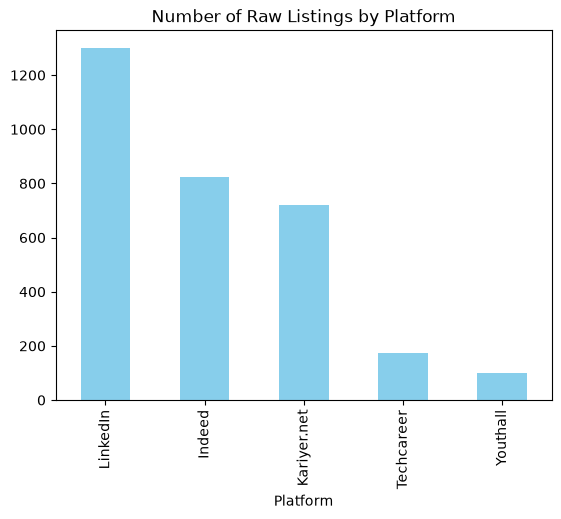

In [201]:
df_raw['Platform'].value_counts().plot(kind='bar', color='skyblue', title='Number of Raw Listings by Platform')
plt.show()

In [202]:
df_clean = pd.read_csv("../data/processed/cleaned_data.csv")
print(f"Number of Cleaned Ads: {len(df_clean)}")

Number of Cleaned Ads: 2437


In [203]:
df_clean.sample(n=5)

,Platform,Search_Keyword,Job_Title,Company,Location_Details,Job_Type,Job_Description,Job_Link,Logo_Link,Required_Skills,first_seen,last_seen,Work_Model,Experience_Level
298,LinkedIn,yazılım geliştirici,SENIOR DEVELOPER,Turkcell,İstanbul,Full-time,Direct message the job poster from Turkcell\n\...,https://tr.linkedin.com/jobs/view/senior-devel...,https://media.licdn.com/dms/image/v2/D4D0BAQG_...,"javascript, typescript, react, git, ci/cd, htm...",2026-07-28,2026-07-28,On-site,Senior
1368,LinkedIn,backend,Backend Engineer,Migros One,İstanbul,Full-time,"Who are we?\n\nOur business is technology, foo...",https://tr.linkedin.com/jobs/view/backend-engi...,https://media.licdn.com/dms/image/v2/D4D0BAQFg...,"java, mysql, postgresql, aws, docker, kubernet...",2026-07-19,2026-07-19,On-site,Not specified
1783,Techcareer,NaN,Netsis ERP Destek Uzmanı,SİBERLOG VERİ GÜVENLİĞİ VE BİLİŞİM HİZMETLERİ ...,Antalya,Full-time,Bilgi Teknolojileri / IT sektöründe faaliyet g...,https://www.techcareer.net/jobs/detail/netsis-...,https://www.techcareer.net/_next/image?url=htt...,netsis,2026-07-19,2026-07-19,On-site,Not specified
78,Kariyer.net,java,Yazılım Mühendisi\naccessible,Omuz Omuza Engelsiz İnsan Kaynakları,İstanbul,Full-time,Danışmanlığını yapmakta olduğumuz bilişim tekn...,https://www.kariyer.net/is-ilani/omuz-omuza-en...,"data:image/svg+xml;charset=UTF-8,%3Csvg%20widt...","javascript, sql, html, css",2026-07-28,2026-07-28,On-site,Not specified
788,LinkedIn,machine learning,Senior AI Engineer,Gini Talent,İstanbul,Full-time,Senior AI Engineer\n\nFull-time - Hybrid\n\n\n...,https://tr.linkedin.com/jobs/view/senior-a%C4%...,https://media.licdn.com/dms/image/v2/C4D0BAQFq...,machine learning,2026-07-19,2026-07-19,On-site,Senior


In [204]:
df_clean['Work_Model'].value_counts()

Work_Model
On-site    2377
Hybrid       53
Remote        7
Name: count, dtype: int64

In [205]:
df_clean['Job_Type'].value_counts()

Job_Type
Full-time    2309
Intern         79
Freelance      28
Part-time      21
Name: count, dtype: int64

In [206]:
df_clean['Experience_Level'].value_counts()

Experience_Level
Lead/Manager     838
Not specified    716
Senior           592
Mid-Level        179
Junior           112
Name: count, dtype: int64

In [207]:
df_clean['Location_Details']


0              Ankara
1               İzmir
2            İstanbul
3            İstanbul
4              Ankara
            ...      
2432    Not specified
2433    Not specified
2434    Not specified
2435           İZmit
2436         İstanbul
Name: Location_Details, Length: 2437, dtype: str

In [208]:
df_clean.columns

Index(['Platform', 'Search_Keyword', 'Job_Title', 'Company',
       'Location_Details', 'Job_Type', 'Job_Description', 'Job_Link',
       'Logo_Link', 'Required_Skills', 'first_seen', 'last_seen', 'Work_Model',
       'Experience_Level'],
      dtype='str')

In [209]:
df_clean['Experience_Level'].value_counts()

Experience_Level
Lead/Manager     838
Not specified    716
Senior           592
Mid-Level        179
Junior           112
Name: count, dtype: int64

In [210]:
df_clean['Job_Title'].value_counts()

Job_Title
Software Engineer                                                              18
Yazılım Mühendisi                                                              16
Data Analyst                                                                   14
Backend Developer                                                              14
DevOps Engineer                                                                14
                                                                               ..
AI-Native Software Engineering Director (OTE $100,000/year USD), @Sparkrock     1
Game Tech Lead (UE5 / Multiplayer Systems)                                      1
Digital Marketing & AI Specialist                                               1
Process Engineer                                                                1
CRM Uzmanı                                                                      1
Name: count, Length: 1882, dtype: int64

C:\Users\HP\AppData\Local\Temp\ipykernel_20832\503496978.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_companies.index, x=top_companies.values, palette="viridis")


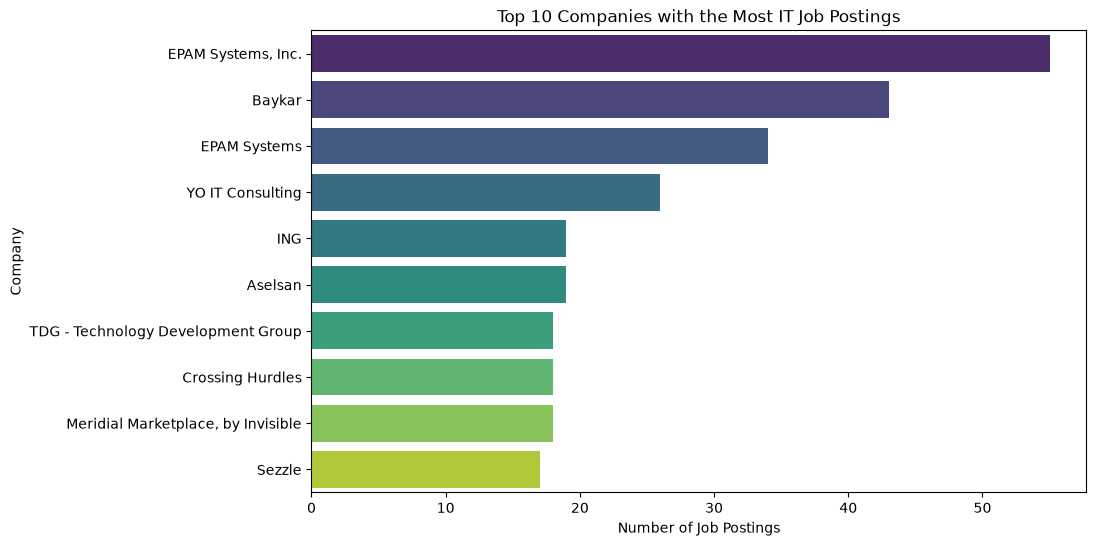

In [211]:
plt.figure(figsize=(10, 6))
top_companies = df_clean['Company'].value_counts().head(10)
sns.barplot(y=top_companies.index, x=top_companies.values, palette="viridis")
plt.title("Top 10 Companies with the Most IT Job Postings")
plt.xlabel("Number of Job Postings")
plt.ylabel("Company")
plt.show()

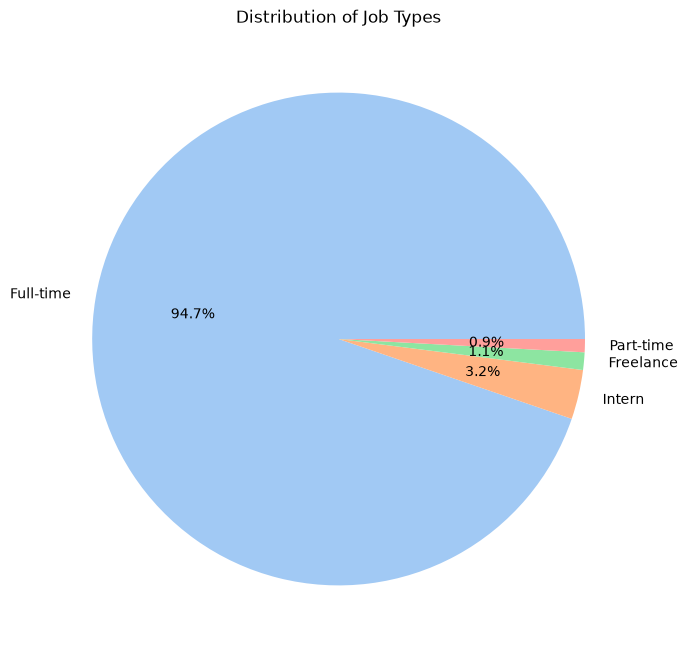

In [212]:
plt.figure(figsize=(8, 8))
job_types = df_clean['Job_Type'].value_counts()
plt.pie(job_types.values, labels=job_types.index, autopct='%1.1f%%', colors=sns.color_palette("pastel"))
plt.title("Distribution of Job Types")
plt.show()

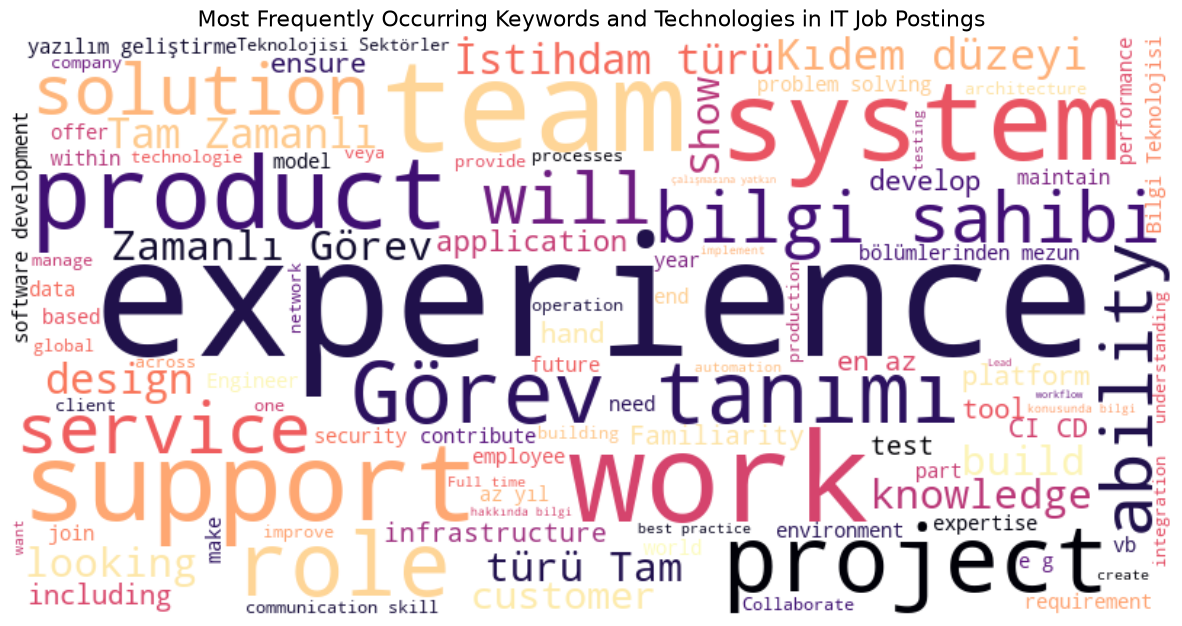

In [213]:
text = " ".join(desc for desc in df_clean['Job_Description'].dropna())

wordcloud = WordCloud(width=800, height=400, background_color="white", colormap="magma", max_words=100).generate(text)

plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Most Frequently Occurring Keywords and Technologies in IT Job Postings", fontsize=16)
plt.show()

## Model3 
### Spatial Separation Map with UMAP

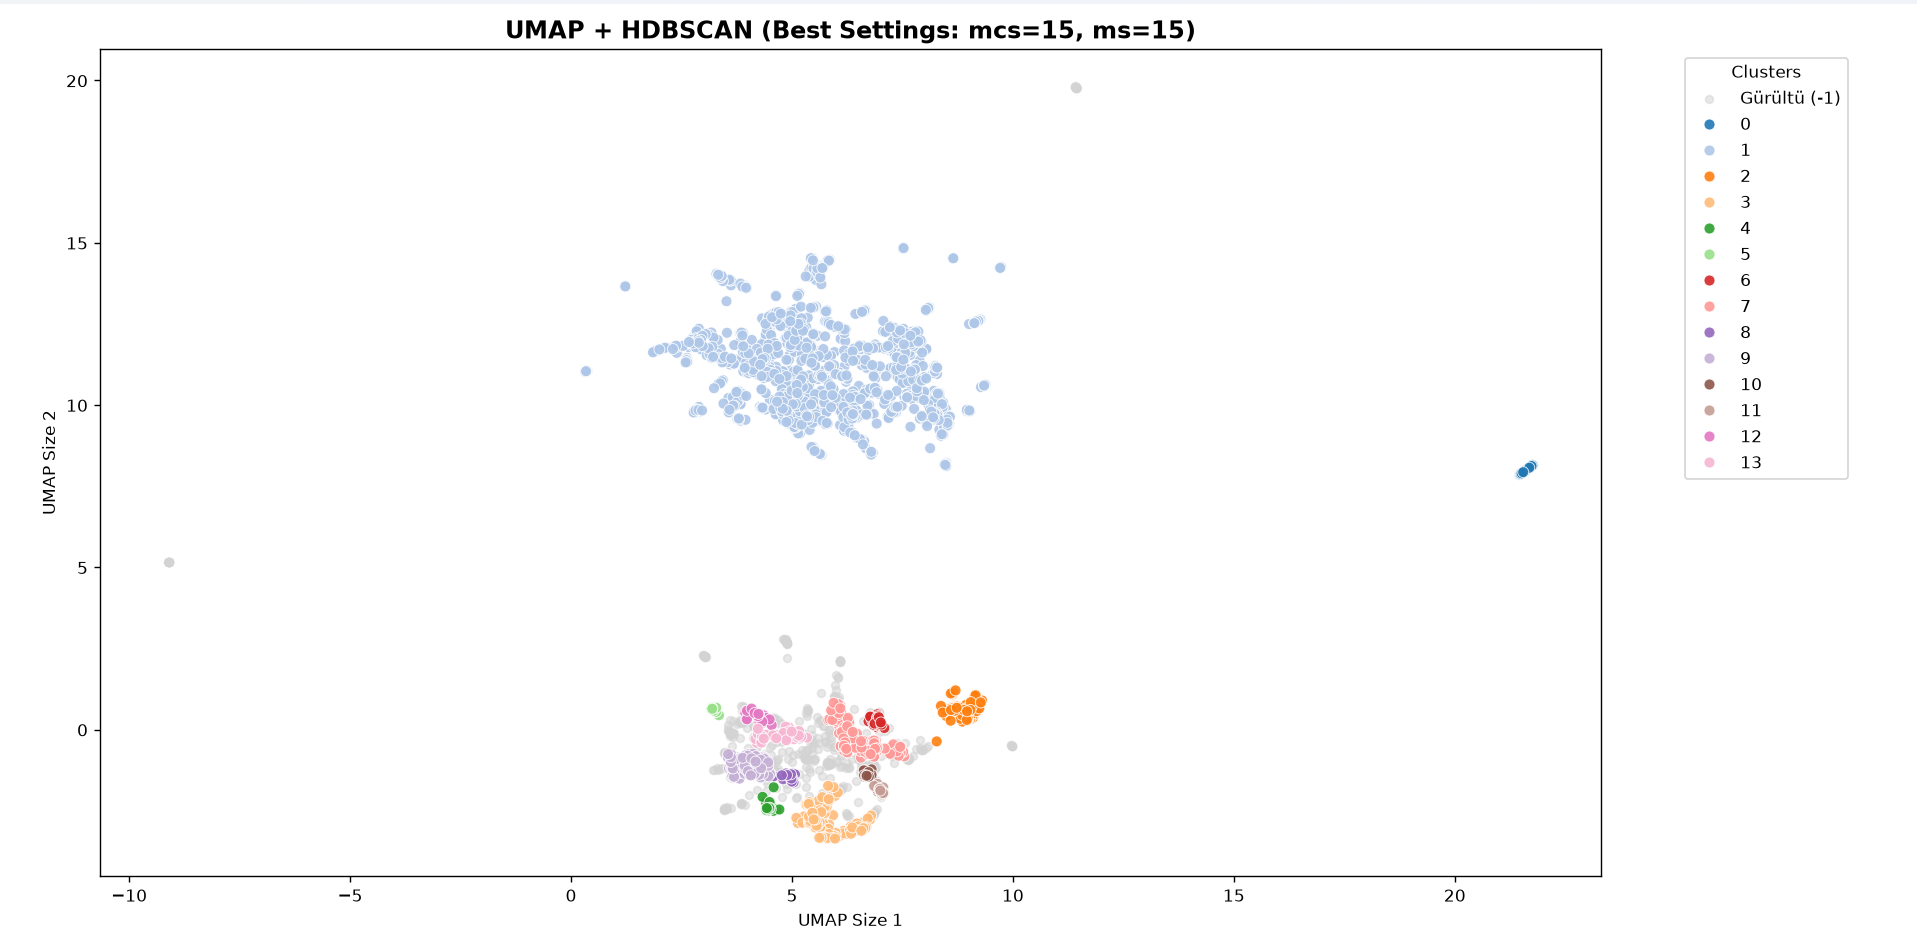

In [218]:
df_domain = pd.read_csv("../data/processed/labeled_domain_data.csv")
print(len(df_domain))

2068


In [215]:
df_domain.columns

Index(['Platform', 'Search_Keyword', 'Job_Title', 'Company',
       'Location_Details', 'Job_Type', 'Job_Description', 'Job_Link',
       'Logo_Link', 'Required_Skills', 'first_seen', 'last_seen', 'Work_Model',
       'Experience_Level', 'Job_Domain'],
      dtype='str')

In [216]:
df_domain.sample(5)

,Platform,Search_Keyword,Job_Title,Company,Location_Details,Job_Type,Job_Description,Job_Link,Logo_Link,Required_Skills,first_seen,last_seen,Work_Model,Experience_Level,Job_Domain
512,LinkedIn,data analyst,"Lead Data Analyst, Ruby",Rovio Entertainment,İzmir,Full-time,Rovio is part of the SEGA family and world fam...,https://tr.linkedin.com/jobs/view/lead-data-an...,https://media.licdn.com/dms/image/v2/D4D0BAQFF...,"python, sql, excel, ruby",2026-07-19,2026-07-19,On-site,Lead/Manager,Data & AI
1149,LinkedIn,backend,Backend Developer,obilet,İstanbul,Full-time,obilet şirketinde iş ilanını yayınlayan kişiye...,https://tr.linkedin.com/jobs/view/backend-deve...,https://media.licdn.com/dms/image/v2/C4D0BAQHk...,"aws, docker, git",2026-07-19,2026-07-19,On-site,Lead/Manager,Backend
739,LinkedIn,data scientist,Python Coding Specialist - Freelance AI Traine...,"Meridial Marketplace, by Invisible",Not specified,Freelance,Are you a coding expert fluent in Python eager...,https://tr.linkedin.com/jobs/view/python-codin...,https://media.licdn.com/dms/image/v2/D4D0BAQHx...,python,2026-07-19,2026-07-19,On-site,Senior,Data & AI
1370,Techcareer,NaN,Bilgi İşlem Uzmanı,T Shop Kozmetik,İstanbul,Full-time,İş Tanımı\n\nŞirketimizin bilgi işlem süreçler...,https://www.techcareer.net/jobs/detail/bilgi-i...,https://www.techcareer.net/_next/image?url=htt...,"Çözüm Odaklı, Analitik Düşünme, Pratik Düşünce",2026-07-19,2026-07-19,On-site,Lead/Manager,"System, Network & IT Ops"
1959,Indeed,software developer,Developer Relations AI (100% remote Worldwide),Tether Operations Limited,İstanbul,Full-time,Join Tether and Shape the Future of Digital Fi...,https://tr.indeed.com/viewjob?jk=2cbb387ab0603781,No Logo,"javascript, typescript, node",2026-07-19,2026-07-19,On-site,Lead/Manager,Data & AI


In [219]:
df_pred = pd.read_csv("../data/processed/predicted_data.csv")
print(len(df_pred))

2437


In [223]:
df_pred.sample(5)

,Platform,Search_Keyword,Job_Title,Company,Location_Details,Job_Type,Job_Description,Job_Link,Logo_Link,Required_Skills,first_seen,last_seen,Work_Model,Experience_Level,Job_Domain,Cluster_ID,Cluster_X,Cluster_Y
1061,LinkedIn,siber güvenlik,Penetration Tester,İnnova Bilişim,İstanbul,Full-time,İnnova Bilişim şirketinde iş ilanını yayınlaya...,https://tr.linkedin.com/jobs/view/penetration-...,https://media.licdn.com/dms/image/v2/D4D0BAQHR...,Not specified,2026-07-19,2026-07-19,On-site,Junior,Cybersecurity,-1,3.4817,-2.4919
714,LinkedIn,artificial intelligence,"Chatbot Developer (WhatsApp, Telegram, Discord...",Mindrift,Not specified,Freelance,Mindrift is looking for skilled Bot Developers...,https://tr.linkedin.com/jobs/view/chatbot-deve...,https://media.licdn.com/dms/image/v2/D4D0BAQG9...,"python, node, nosql, docker",2026-07-19,2026-07-19,On-site,Lead/Manager,DevOps & Cloud,1,4.2805,10.5517
1241,LinkedIn,cyber security,Cyber Security Monitoring Engineer (SIEM/SOC),ColendiBank,İstanbul,Full-time,ColendiBank şirketinde iş ilanını yayınlayan k...,https://tr.linkedin.com/jobs/view/cyber-securi...,https://media.licdn.com/dms/image/v2/D4D0BAQFO...,Not specified,2026-07-19,2026-07-19,On-site,Lead/Manager,Cybersecurity,1,7.8202,12.1899
2382,Indeed,software developer,Embedded System Software Developer,DTSİS Dijital Tanıma Sistemleri,İstanbul,Full-time,Embedded System Software Developer\n\nJob Desc...,https://tr.indeed.com/viewjob?jk=1fc033953da13faf,No Logo,linux,2026-07-19,2026-07-19,On-site,Senior,"System, Network & IT Ops",1,6.4072,9.0557
1897,Kariyer.net,data engineer,Fresh Grad IT Engineer,Randstad Türkiye,İstanbul,Full-time,Job Overview\n\nWe are looking for an energeti...,https://www.kariyer.net/is-ilani/randstad-turk...,"data:image/svg+xml;charset=UTF-8,%3Csvg%20widt...",Not specified,2026-07-19,2026-07-19,On-site,Senior,General Software,1,7.1911,11.7569
